In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [16]:
df = pd.read_excel('Потребление электроэнергии на юго-востоке Бразилии.xlsx')
df = df.T.reset_index()
df.columns = ['Дата', 'Потребление']
df['Дата'] = df['Дата'].apply(lambda x: pd.to_datetime(x, format = '%Y-%m-%d', errors=  'coerce'))
df

,Дата,Потребление
0,2009-01-01,6.565180e+05
1,2009-02-01,7.231930e+05
2,2009-03-01,8.183063e+05
3,2009-04-01,8.989103e+05
4,2009-05-01,1.027720e+06
...,...,...
91,2016-08-01,1.300039e+06
92,2016-09-01,1.381843e+06
93,2016-10-01,1.405459e+06
94,2016-11-01,1.566660e+06


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 96 entries, 2009-01-01 to 2016-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       96 non-null     float64
dtypes: float64(1)
memory usage: 1.5 KB


In [29]:
from statsmodels.tsa.api import Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error, r2_score

data_range = pd.date_range('2016-01-01', '2016-12-01', periods= 12)
holt_winters = ExponentialSmoothing(df['Потребление'].iloc[:84], seasonal= 'add', trend = 'add', damped_trend= True, \
                                    seasonal_periods= 12, initialization_method= 'estimated')
holt_winters = holt_winters.fit()
future = holt_winters.forecast(len(data_range))
df_future = pd.DataFrame({'Дата': list(data_range), 'Потребление': list(future)})

df_real = df.iloc[84:]
MSE, R2 = mean_squared_error(df_real['Потребление'], df_future['Потребление']), r2_score(df_real['Потребление'], df_future['Потребление'])
RMSE =np.sqrt(mean_squared_error(df_real['Потребление'], df_future['Потребление']))
print(f'metrics of forecasting: MSE, R2, RMSE: {MSE}, {R2}, {RMSE}')

metrics of forecasting: MSE, R2, RMSE: 20375000591.53178, 0.6680563508646107, 142741.0263082474


/home/abu/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,Дата,Потребление
0,2009-01-01,6.565180e+05
1,2009-02-01,7.231930e+05
2,2009-03-01,8.183063e+05
3,2009-04-01,8.989103e+05
4,2009-05-01,1.027720e+06
...,...,...
91,2016-08-01,1.300039e+06
92,2016-09-01,1.381843e+06
93,2016-10-01,1.405459e+06
94,2016-11-01,1.566660e+06


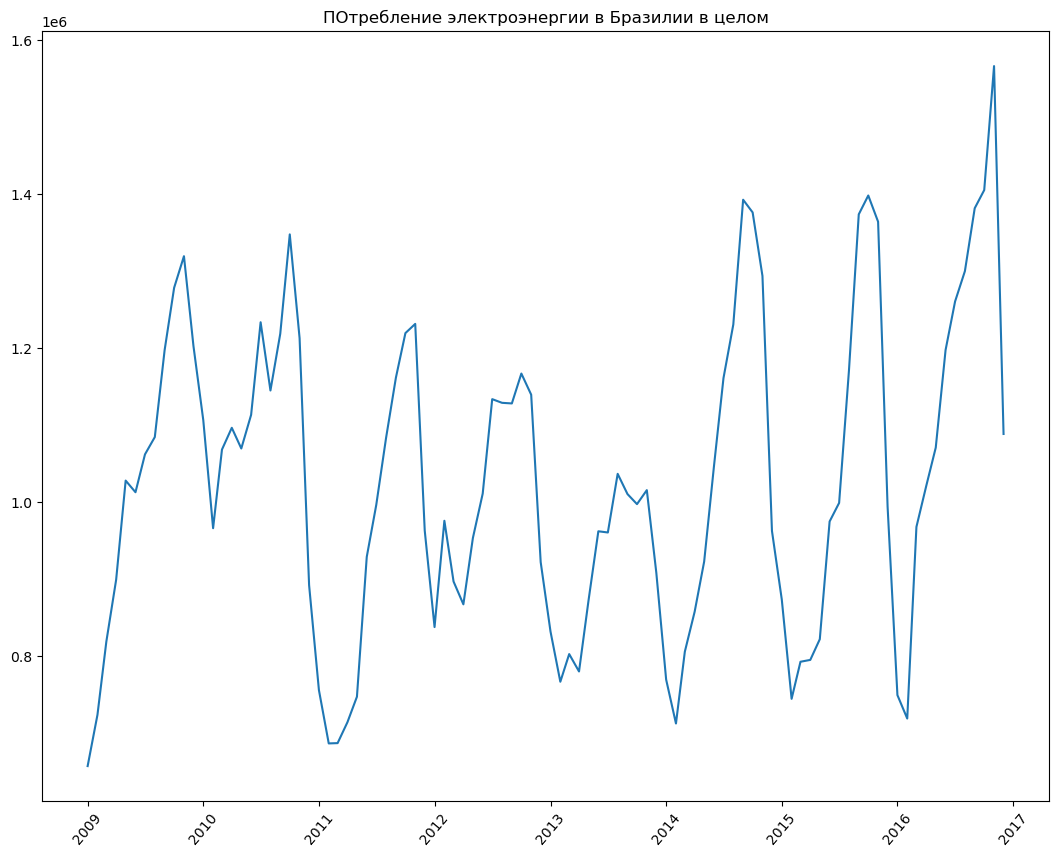

In [41]:
fig = plt.figure(figsize = (13, 10))
plt.plot(df['Дата'], df['Потребление'])
plt.title('ПОтребление электроэнергии в Бразилии в целом')
plt.xticks(rotation  = 50)
df

,Дата,Потребление
0,2016-01-01 00:00:00.000000000,8.992243e+05
1,2016-01-31 10:54:32.727272727,8.714610e+05
2,2016-03-01 21:49:05.454545455,8.936798e+05
3,2016-04-01 08:43:38.181818182,9.041447e+05
4,2016-05-01 19:38:10.909090910,9.611846e+05
5,2016-06-01 06:32:43.636363638,1.065432e+06
6,2016-07-01 17:27:16.363636364,1.146094e+06
7,2016-08-01 04:21:49.090909092,1.152502e+06
8,2016-08-31 15:16:21.818181820,1.222847e+06
9,2016-10-01 02:10:54.545454548,1.305483e+06


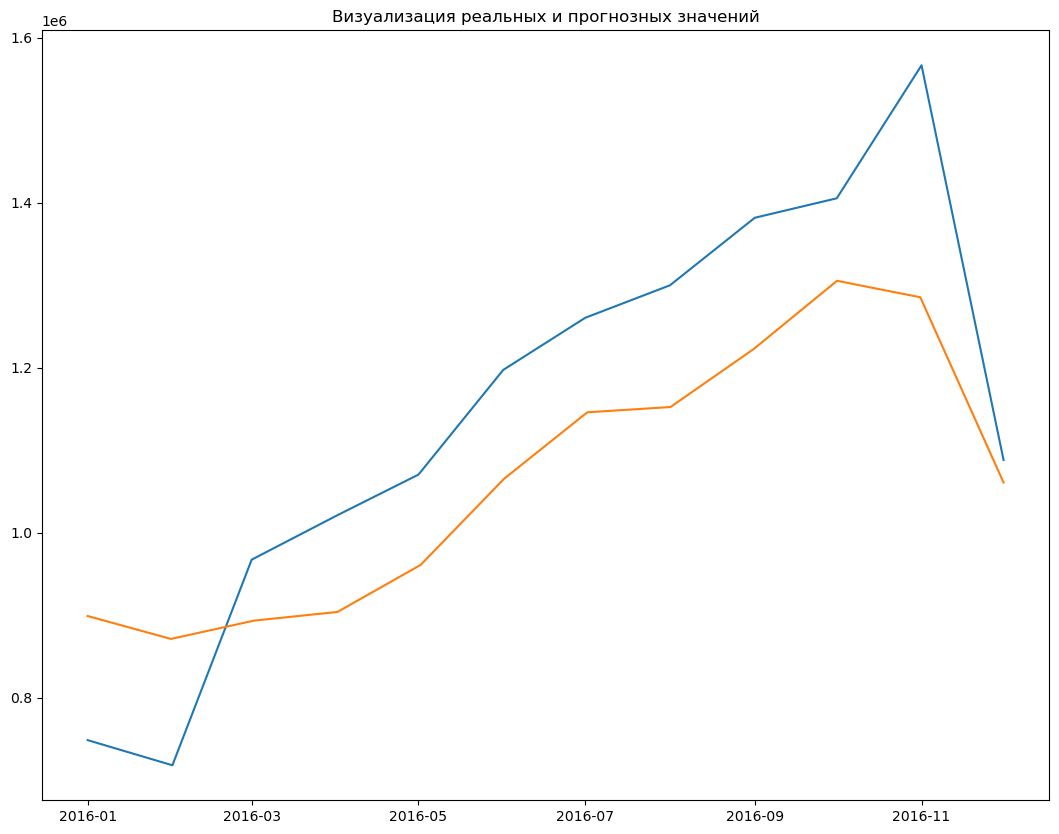

In [44]:
fig = plt.figure(figsize = (13, 10))
plt.plot(df_real['Дата'], df_real['Потребление'], label = 'Реальные значения')
plt.plot(df_future['Дата'], df_future['Потребление'], label = 'Holt-Winters')
plt.title('Визуализация реальных и прогнозных значений')


/home/abu/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


(array([13879., 14245., 14610., 14975., 15340., 15706., 16071., 16436.,
        16801., 17167., 17532.]),
 [Text(13879.0, 0, '2008'),
  Text(14245.0, 0, '2009'),
  Text(14610.0, 0, '2010'),
  Text(14975.0, 0, '2011'),
  Text(15340.0, 0, '2012'),
  Text(15706.0, 0, '2013'),
  Text(16071.0, 0, '2014'),
  Text(16436.0, 0, '2015'),
  Text(16801.0, 0, '2016'),
  Text(17167.0, 0, '2017'),
  Text(17532.0, 0, '2018')])

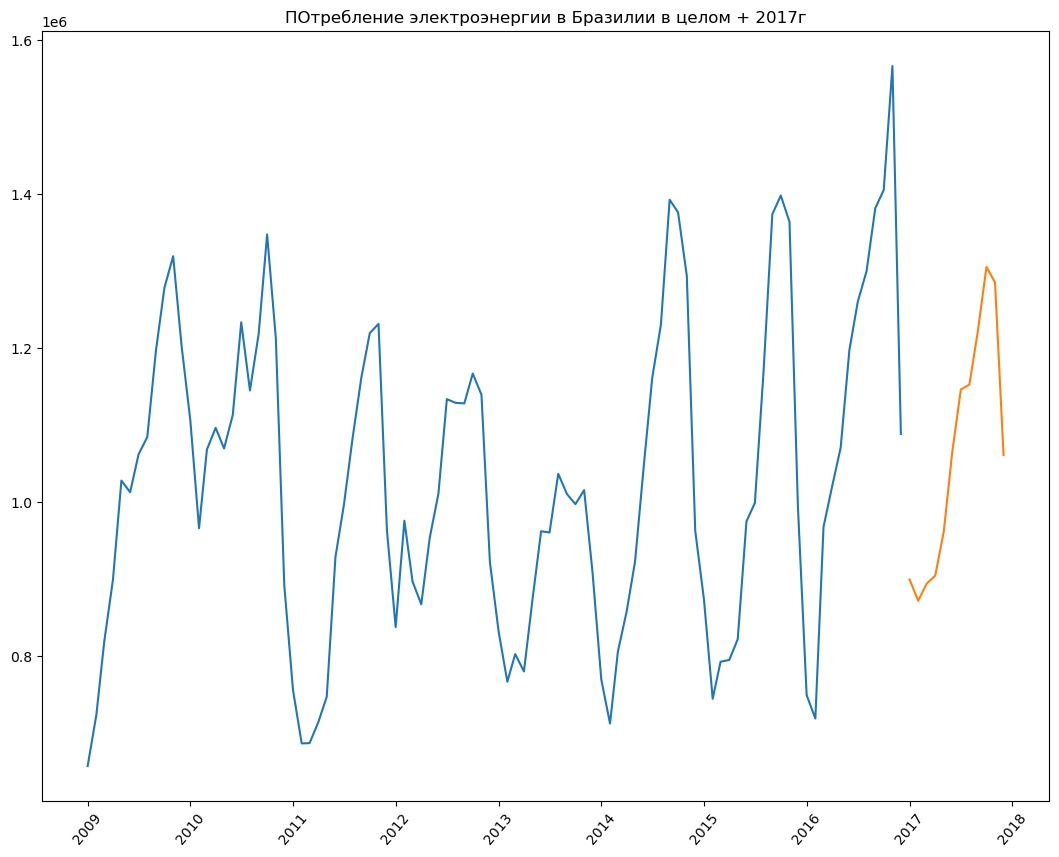

In [46]:
data_range = pd.date_range('2017-01-01', '2017-12-01', periods= 12)
holt_winters = ExponentialSmoothing(df['Потребление'].iloc[:84], seasonal= 'add', trend = 'add', damped_trend= True, \
                                    seasonal_periods= 12, initialization_method= 'estimated')
holt_winters = holt_winters.fit()
future = holt_winters.forecast(len(data_range))
df_future = pd.DataFrame({'Дата': list(data_range), 'Потребление': list(future)})

fig = plt.figure(figsize = (13, 10))
plt.plot(df['Дата'], df['Потребление'], label = 'Исторические данные')
plt.plot(df_future['Дата'], df_future['Потребление'], label = 'Прогнозные данные на следующий период')
plt.title('ПОтребление электроэнергии в Бразилии в целом + 2017г')
plt.xticks(rotation  = 50)
